# Goodreads Interactions EDA

Notebook này phân tích file `goodreads_interactions.csv` trong Google Drive và tập trung vào các thống kê quan trọng cho pipeline recommender.

Yêu cầu bắt buộc đã được đưa vào notebook:
- Số lượng sách có hơn 5 đánh giá
- Số lượng sách có hơn 10 đánh giá
- Số lượng sách có hơn 100 đánh giá
- Biểu đồ phân bổ số lượng đánh giá của sách

Notebook được thiết kế để chạy trên Colab, mount Drive trực tiếp và dùng DuckDB để tránh nạp toàn bộ dữ liệu vào RAM.

## 1. Kết nối Google Drive

Nếu notebook chạy trên Colab, dữ liệu sẽ được đọc từ `MyDrive/Thesis/Data`. Notebook có kiểm tra cả hai biến thể path phổ biến của Colab.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip -q install duckdb

In [4]:
import gc
import json
import os
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 120

DRIVE_BASE_CANDIDATES = [
    '/content/drive/MyDrive/Thesis/Data',
    '/content/drive/My Drive/Thesis/Data',
]

BASE_DIR = next((path for path in DRIVE_BASE_CANDIDATES if os.path.exists(path)), DRIVE_BASE_CANDIDATES[0])
INTERACTIONS_FILE = os.path.join(BASE_DIR, 'goodreads_interactions.csv')
OUTPUT_DIR = '/content/drive/MyDrive/Thesis/book_recsys/notebooks/eda_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def log_ram(label):
    rss_gb = psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)
    print(f'[RAM] {label}: {rss_gb:.2f} GB')

def elapsed_seconds(start_time):
    return time.time() - start_time

def sql_path(path):
    return path.replace("'", "''")

if not os.path.exists(INTERACTIONS_FILE):
    raise FileNotFoundError(f'Not found: {INTERACTIONS_FILE}')

con = duckdb.connect(database=':memory:')
print(f'Base dir: {BASE_DIR}')
print(f'Interactions file: {INTERACTIONS_FILE}')
print(f'File size: {os.path.getsize(INTERACTIONS_FILE) / (1024 ** 3):.2f} GB')
log_ram('after config')

Base dir: /content/drive/MyDrive/Thesis/Data
Interactions file: /content/drive/MyDrive/Thesis/Data/goodreads_interactions.csv
File size: 4.02 GB
[RAM] after config: 0.26 GB


## 2. Kiểm tra schema và mẫu dữ liệu

Phần này giúp xác nhận các cột chính của file và kiểm tra một vài dòng đầu tiên trước khi chạy thống kê lớn.

In [5]:
start_time = time.time()
sample_df = con.execute(f"""
    SELECT *
    FROM read_csv_auto('{sql_path(INTERACTIONS_FILE)}', header=True)
    LIMIT 5
""").df()

print(f'Preview loaded in {elapsed_seconds(start_time):.2f} seconds')
print('Columns:')
print(sample_df.columns.tolist())
display(sample_df)
gc.collect()
log_ram('after preview')

Preview loaded in 1.81 seconds
Columns:
['user_id', 'book_id', 'is_read', 'rating', 'is_reviewed']


,user_id,book_id,is_read,rating,is_reviewed
0,0,948,1,5,0
1,0,947,1,5,1
2,0,946,1,5,0
3,0,945,1,5,0
4,0,944,1,5,0


[RAM] after preview: 0.30 GB


## 3. Tổng quan dữ liệu

Các chỉ số này cho biết quy mô dữ liệu, mức độ thưa của ma trận user-item và tỷ lệ rating bằng 0 so với rating dương.

In [6]:
start_time = time.time()
summary_df = con.execute(f"""
WITH interactions AS (
    SELECT
        CAST(user_id AS VARCHAR) AS user_id,
        CAST(book_id AS VARCHAR) AS book_id,
        TRY_CAST(rating AS INTEGER) AS rating
    FROM read_csv_auto('{sql_path(INTERACTIONS_FILE)}', header=True)
),
positive AS (
    SELECT *
    FROM interactions
    WHERE rating > 0
)
SELECT
    COUNT(*) AS total_interactions,
    COUNT(DISTINCT user_id) AS unique_users,
    COUNT(DISTINCT book_id) AS unique_books,
    SUM(CASE WHEN rating IS NULL THEN 1 ELSE 0 END) AS null_rating_rows,
    SUM(CASE WHEN rating = 0 THEN 1 ELSE 0 END) AS zero_rating_rows,
    SUM(CASE WHEN rating > 0 THEN 1 ELSE 0 END) AS positive_rating_rows,
    (SELECT AVG(rating) FROM positive) AS mean_positive_rating,
    (SELECT quantile_cont(rating, 0.5) FROM positive) AS median_positive_rating,
    (SELECT MIN(rating) FROM positive) AS min_positive_rating,
    (SELECT MAX(rating) FROM positive) AS max_positive_rating
FROM interactions
""").df()

row = summary_df.iloc[0]
density = row['total_interactions'] / (row['unique_users'] * row['unique_books'])
sparsity = 1 - density

mean_positive_rating = f"{row['mean_positive_rating']:.4f}" if pd.notna(row['mean_positive_rating']) else 'NA'
median_positive_rating = f"{row['median_positive_rating']:.4f}" if pd.notna(row['median_positive_rating']) else 'NA'
min_positive_rating = int(row['min_positive_rating']) if pd.notna(row['min_positive_rating']) else 'NA'
max_positive_rating = int(row['max_positive_rating']) if pd.notna(row['max_positive_rating']) else 'NA'

summary_table = pd.DataFrame([
    {'metric': 'Total interactions', 'value': int(row['total_interactions'])},
    {'metric': 'Unique users', 'value': int(row['unique_users'])},
    {'metric': 'Unique books', 'value': int(row['unique_books'])},
    {'metric': 'Positive rating rows', 'value': int(row['positive_rating_rows'])},
    {'metric': 'Zero rating rows', 'value': int(row['zero_rating_rows'])},
    {'metric': 'Null rating rows', 'value': int(row['null_rating_rows'])},
    {'metric': 'Density', 'value': f'{density:.8f}'},
    {'metric': 'Sparsity (%)', 'value': f'{sparsity * 100:.6f}'},
    {'metric': 'Mean positive rating', 'value': mean_positive_rating},
    {'metric': 'Median positive rating', 'value': median_positive_rating},
    {'metric': 'Min positive rating', 'value': min_positive_rating},
    {'metric': 'Max positive rating', 'value': max_positive_rating},
])

display(summary_table)
print(f'Loaded summary in {elapsed_seconds(start_time):.2f} seconds')
gc.collect()
log_ram('after summary')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

RuntimeError: Query interrupted

## 4. Phân phối rating của interactions

Biểu đồ này cho biết tập dữ liệu có nghiêng về rating thấp, rating cao hay tập trung ở một vài mức rating cụ thể.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rating_value,row_count,pct
0,0,124096793,54.274084
1,1,2050529,0.896805
2,2,6189946,2.707190
3,3,23307457,10.193582
4,4,37497451,16.399616
5,5,35506166,15.528722


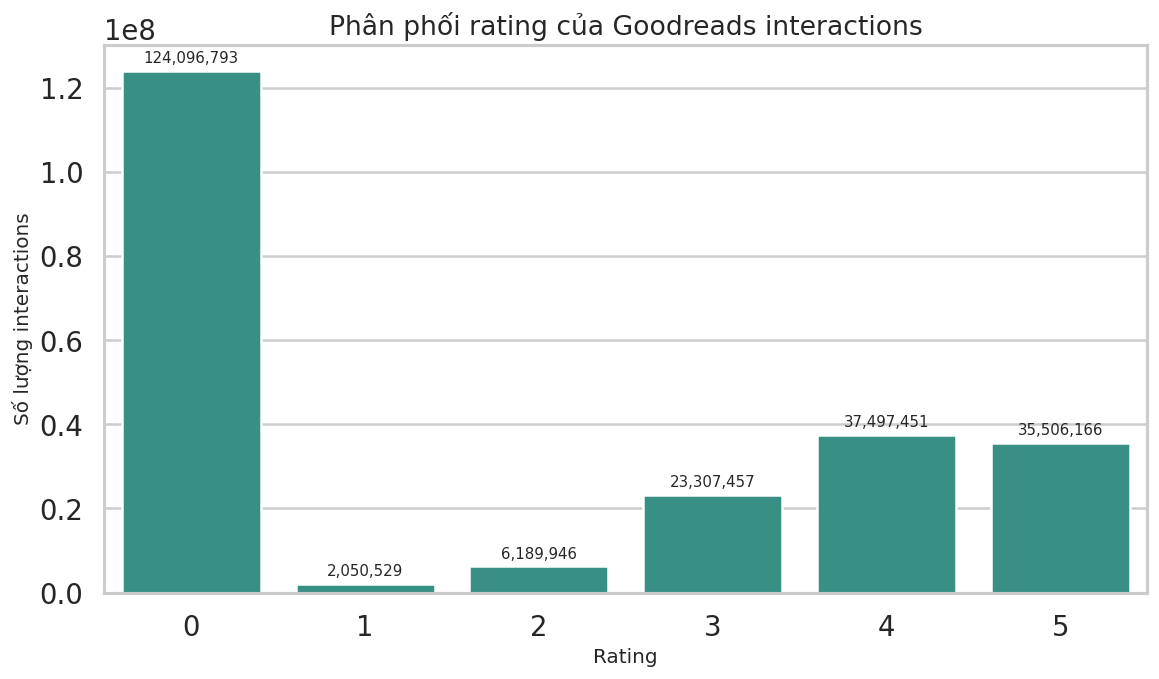

Plotted rating distribution in 66.90 seconds
[RAM] after rating distribution: 0.35 GB


In [ ]:
start_time = time.time()
rating_dist_df = con.execute(f"""
WITH interactions AS (
    SELECT TRY_CAST(rating AS INTEGER) AS rating
    FROM read_csv_auto('{sql_path(INTERACTIONS_FILE)}', header=True)
)
SELECT
    COALESCE(CAST(rating AS VARCHAR), 'NULL') AS rating_value,
    COUNT(*) AS row_count,
    CASE WHEN rating IS NULL THEN -1 ELSE rating END AS sort_key
FROM interactions
GROUP BY 1, 3
ORDER BY sort_key
""").df()

total_rows = rating_dist_df['row_count'].sum()
rating_dist_df['pct'] = rating_dist_df['row_count'] / total_rows * 100

display(rating_dist_df[['rating_value', 'row_count', 'pct']])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=rating_dist_df, x='rating_value', y='row_count', ax=ax, color='#2a9d8f')
ax.set_title('Phân phối rating của Goodreads interactions')
ax.set_xlabel('Rating')
ax.set_ylabel('Số lượng interactions')
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f'{int(height):,}', (patch.get_x() + patch.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

print(f'Plotted rating distribution in {elapsed_seconds(start_time):.2f} seconds')
gc.collect()
log_ram('after rating distribution')

## 5. Thống kê theo sách và các ngưỡng bắt buộc

Ở đây `positive_rating_count` được hiểu là số lượt rating dương của một cuốn sách. Bảng dưới đây trả lời trực tiếp các yêu cầu `>5`, `>10`, và `>100` đánh giá.

In [ ]:
start_time = time.time()
con.execute(f"""
CREATE OR REPLACE TEMP TABLE book_stats AS
SELECT
    CAST(book_id AS VARCHAR) AS book_id,
    COUNT(*) AS interaction_count,
    SUM(CASE WHEN TRY_CAST(rating AS INTEGER) > 0 THEN 1 ELSE 0 END) AS positive_rating_count
FROM read_csv_auto('{sql_path(INTERACTIONS_FILE)}', header=True)
GROUP BY 1
""")

book_summary_df = con.execute("""
SELECT
    COUNT(*) AS unique_books,
    SUM(CASE WHEN positive_rating_count > 5 THEN 1 ELSE 0 END) AS books_gt_5,
    SUM(CASE WHEN positive_rating_count > 10 THEN 1 ELSE 0 END) AS books_gt_10,
    SUM(CASE WHEN positive_rating_count > 100 THEN 1 ELSE 0 END) AS books_gt_100,
    AVG(positive_rating_count) AS avg_positive_rating_count,
    quantile_cont(positive_rating_count, 0.5) AS median_positive_rating_count,
    quantile_cont(positive_rating_count, 0.9) AS p90_positive_rating_count,
    quantile_cont(positive_rating_count, 0.99) AS p99_positive_rating_count
FROM book_stats
""").df()

book_row = book_summary_df.iloc[0]
threshold_table = pd.DataFrame([
    {'threshold': '> 5 ratings', 'books': int(book_row['books_gt_5'])},
    {'threshold': '> 10 ratings', 'books': int(book_row['books_gt_10'])},
    {'threshold': '> 100 ratings', 'books': int(book_row['books_gt_100'])},
])
threshold_table['share_of_books_%'] = threshold_table['books'] / int(book_row['unique_books']) * 100

display(book_summary_df)
display(threshold_table)

print(f'Computed book statistics in {elapsed_seconds(start_time):.2f} seconds')
gc.collect()
log_ram('after book stats')

In [ ]:
book_bins_df = con.execute("""
SELECT
    count_bin,
    COUNT(*) AS num_books,
    sort_key
FROM (
    SELECT
        CASE
            WHEN positive_rating_count = 0 THEN '0'
            WHEN positive_rating_count BETWEEN 1 AND 5 THEN '1-5'
            WHEN positive_rating_count BETWEEN 6 AND 10 THEN '6-10'
            WHEN positive_rating_count BETWEEN 11 AND 25 THEN '11-25'
            WHEN positive_rating_count BETWEEN 26 AND 50 THEN '26-50'
            WHEN positive_rating_count BETWEEN 51 AND 100 THEN '51-100'
            WHEN positive_rating_count BETWEEN 101 AND 250 THEN '101-250'
            WHEN positive_rating_count BETWEEN 251 AND 500 THEN '251-500'
            WHEN positive_rating_count BETWEEN 501 AND 1000 THEN '501-1000'
            ELSE '>1000'
        END AS count_bin,
        CASE
            WHEN positive_rating_count = 0 THEN 0
            WHEN positive_rating_count BETWEEN 1 AND 5 THEN 1
            WHEN positive_rating_count BETWEEN 6 AND 10 THEN 2
            WHEN positive_rating_count BETWEEN 11 AND 25 THEN 3
            WHEN positive_rating_count BETWEEN 26 AND 50 THEN 4
            WHEN positive_rating_count BETWEEN 51 AND 100 THEN 5
            WHEN positive_rating_count BETWEEN 101 AND 250 THEN 6
            WHEN positive_rating_count BETWEEN 251 AND 500 THEN 7
            WHEN positive_rating_count BETWEEN 501 AND 1000 THEN 8
            ELSE 9
        END AS sort_key
    FROM book_stats
) t
GROUP BY count_bin, sort_key
ORDER BY sort_key
""").df()

top_books_df = con.execute("""
SELECT
    book_id,
    positive_rating_count,
    interaction_count
FROM book_stats
ORDER BY positive_rating_count DESC, book_id ASC
LIMIT 20
""").df()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=book_bins_df, x='count_bin', y='num_books', ax=axes[0], color='#264653')
axes[0].set_yscale('log')
axes[0].set_title('Phân bổ số rating của sách')
axes[0].set_xlabel('Số rating trên mỗi sách')
axes[0].set_ylabel('Số lượng sách (log scale)')
axes[0].tick_params(axis='x', rotation=45)

top_books_plot = top_books_df.sort_values('positive_rating_count', ascending=True)
sns.barplot(data=top_books_plot, y='book_id', x='positive_rating_count', ax=axes[1], palette='viridis')
axes[1].set_title('Top 20 sách theo số rating dương')
axes[1].set_xlabel('Số rating dương')
axes[1].set_ylabel('book_id')

plt.tight_layout()
plt.show()

display(book_bins_df)
display(top_books_df)
gc.collect()
log_ram('after book plots')

## 6. Kết luận nhanh

Sau khi chạy notebook, các con số quan trọng nhất cần nhìn lại là:
- `books_gt_5`, `books_gt_10`, `books_gt_100`
- `sparsity (%)` của ma trận user-item
- Hình dạng heavy-tail của phân phối rating theo sách
- Top sách có nhiều rating nhất để đánh giá độ lệch phổ biến trong dataset

Notebook này có thể dùng lại làm nền cho bước preprocessing và evaluation sau này.